# **Assignment 1: Implementation of Two Libraries - Tensorflow and Keras - 1. Dataset split 2. Training 3. Evaluation**

In [ ]:
# 1. Importing Libraries
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# 2. Get data and split into train and test datasets
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.fashion_mnist.load_data()



29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# 3. Display Dataset Information

print("Training Images Shape :", train_images.shape)
print("Training Labels Shape :", train_labels.shape)

print("Testing Images Shape :", test_images.shape)
print("Testing Labels Shape :", test_labels.shape)

print("\nData Type :", train_images.dtype)


Training Images Shape : (60000, 28, 28)
Training Labels Shape : (60000,)
Testing Images Shape : (10000, 28, 28)
Testing Labels Shape : (10000,)

Data Type : uint8


In [ ]:
# 4. Scale down values of pixels from 0-255 to 0-1

train_images = train_images /255.0
test_images = test_images / 255.0

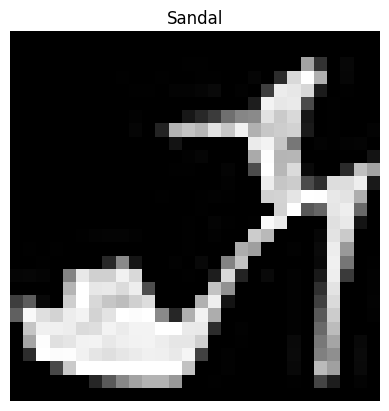

In [ ]:
# 5. Visualizing data
class_names = ['T-shirt/Top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle Boot']
plt.imshow(train_images[9], cmap='gray')
plt.title(class_names[train_labels[9]])
plt.axis('off')
plt.show()

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8244 - loss: 0.4998
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8673 - loss: 0.3704
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8784 - loss: 0.3352
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8682 - loss: 0.3764
Test Loss: 0.3763650357723236
Test Accuracy: 0.8682000041007996


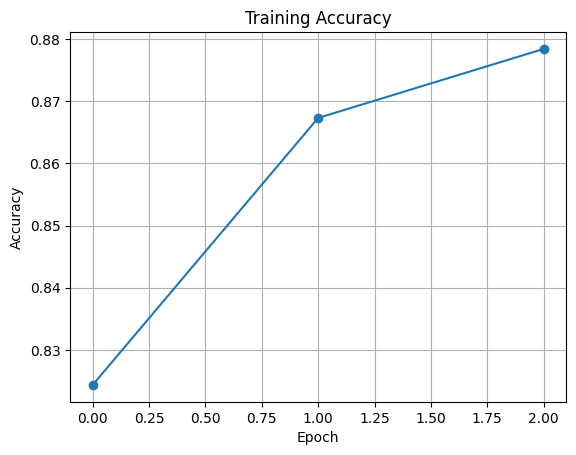

In [ ]:
# 6. Training model
# Define the neural network model
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])
# Compile the model
model.compile( optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# Train the model
history = model.fit( train_images,train_labels,epochs=3)
# Evaluate on test dataset
test_loss, test_accuracy = model.evaluate(test_images, test_labels)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
plt.plot(history.history['accuracy'], marker='o')
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

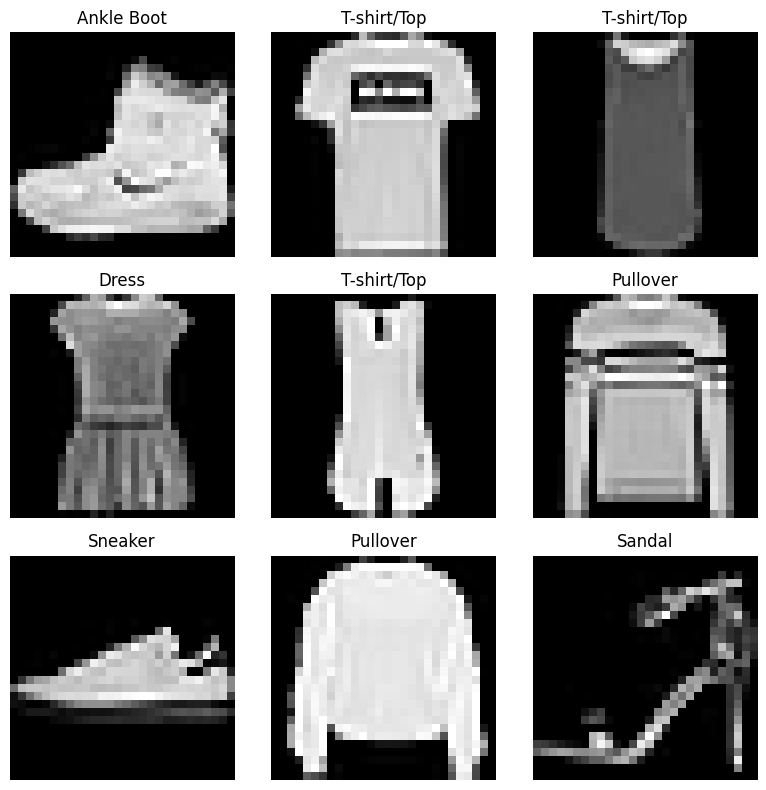

In [ ]:
# 7. Display the classes
plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(train_images[i], cmap='gray')
    plt.title(class_names[train_labels[i]])
    plt.axis('off')

plt.tight_layout()
plt.show()